In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix, precision_score,
    recall_score, f1_score,classification_report
)
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA

In [2]:
df=pd.read_csv('Food_Delivery_Time_Prediction.csv')
df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34


In [3]:
df.isnull().sum()

Order_ID                      0
Customer_Location             0
Restaurant_Location           0
Distance                      0
Weather_Conditions            0
Traffic_Conditions            0
Delivery_Person_Experience    0
Order_Priority                0
Order_Time                    0
Vehicle_Type                  0
Restaurant_Rating             0
Customer_Rating               0
Delivery_Time                 0
Order_Cost                    0
Tip_Amount                    0
dtype: int64

out data has no null or missing values no need to imputation

In [4]:
import numpy as np

# split latitude and longitude
import numpy as np

# remove parentheses
df['Customer_Location'] = df['Customer_Location'].str.replace('(', '', regex=False).str.replace(')', '', regex=False)
df['Restaurant_Location'] = df['Restaurant_Location'].str.replace('(', '', regex=False).str.replace(')', '', regex=False)

# split latitude and longitude
df[['cust_lat','cust_lon']] = df['Customer_Location'].str.split(',', expand=True).astype(float)
df[['rest_lat','rest_lon']] = df['Restaurant_Location'].str.split(',', expand=True).astype(float)

# Haversine function using the :contentReference[oaicite:0]{index=0}
def haversine(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians,[lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    R = 6371
    return R * c

# calculate distance
df['Actual_Distance_km'] = haversine(
    df['cust_lat'],
    df['cust_lon'],
    df['rest_lat'],
    df['rest_lon']
)
df=df.drop(['Distance','cust_lat','cust_lon','rest_lat','rest_lon'],axis=1)
df.head()

,Order_ID,Customer_Location,Restaurant_Location,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,Actual_Distance_km
0,ORD0001,"17.030479, 79.743077","12.358515, 85.100083",Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54,775.651198
1,ORD0002,"15.398319, 86.639122","14.174874, 77.025606",Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02,1042.385597
2,ORD0003,"15.687342, 83.888808","19.594748, 82.048482",Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17,476.220706
3,ORD0004,"20.415599, 78.046984","16.915906, 78.278698",Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23,389.912629
4,ORD0005,"14.786904, 78.706532","15.206038, 86.203182",Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34,806.505886


In [5]:
df['Cost_per_km'] = df['Order_Cost'] / df['Actual_Distance_km']
df['Tip_Ratio'] = df['Tip_Amount'] / df['Order_Cost']
df['Delivery_Speed'] = df['Actual_Distance_km'] / df['Delivery_Time']
df['Distance_Category'] = pd.cut(df['Actual_Distance_km'], bins=4, labels=[1,2,3,4])

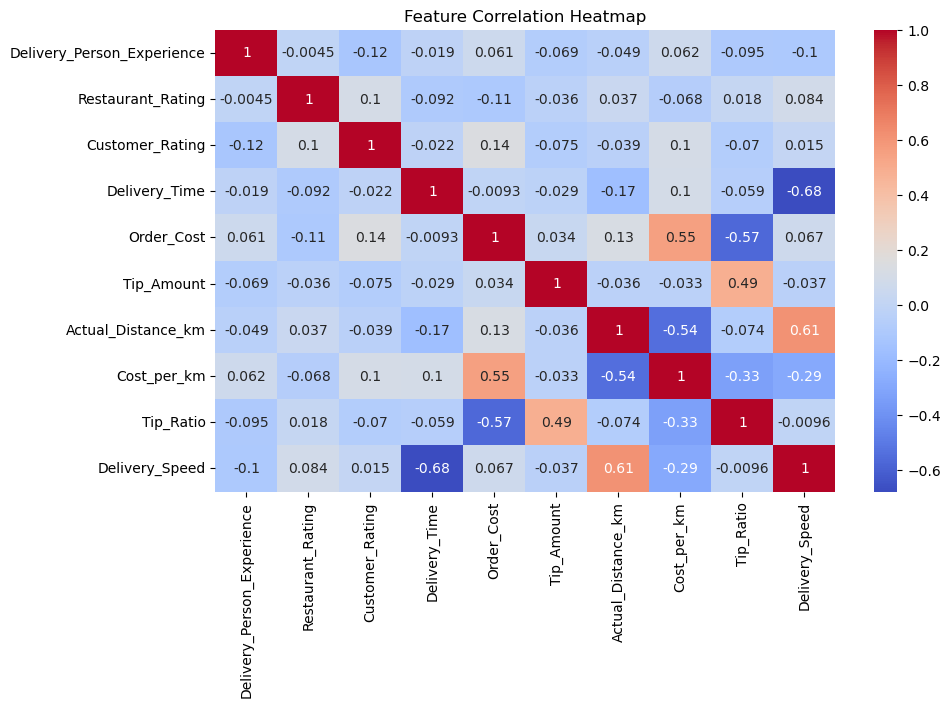

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# calculate correlation matrix
corr = df.corr(numeric_only=True)

# plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Feature Correlation Heatmap")
plt.show()

In [7]:
df=df.drop(['Order_ID','Customer_Location','Restaurant_Location','Tip_Amount','Order_Cost'],axis=1)
df.head()

,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Actual_Distance_km,Cost_per_km,Tip_Ratio,Delivery_Speed,Distance_Category
0,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,775.651198,1.703214,0.061721,29.582426,3
1,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,1042.385597,0.146021,0.190658,16.648868,4
2,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,476.220706,3.452979,0.039024,9.833176,2
3,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,389.912629,1.388131,0.146383,3.492902,2
4,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,806.505886,0.768513,0.003775,24.907532,3


In [8]:
df['Vehicle_Type'].unique()

array(['Car', 'Bike', 'Bicycle'], dtype=object)

In [9]:
ordinal_features = ['Order_Priority', 'Traffic_Conditions','Order_Time']


ordinal_maps = {
    'Order_Priority': {'Low':0, 'Medium':1, 'High':2},
    'Traffic_Conditions': {'Low':0, 'Medium':1, 'High':2},
    'Order_Time':{'Afternoon':0,'Evening':2,'Night':1,'Morning':3},
 #   'Weather_Conditions':{'Sunny':0,'Cloudy':1,"Rainy":2,'Snowy':2},
    


    
}

for col in ordinal_features:
    df[col] = df[col].map(ordinal_maps[col])
df = pd.get_dummies(df, columns=['Vehicle_Type'])

In [10]:
df=pd.get_dummies(df,columns=['Weather_Conditions'])

In [11]:
#df=df.drop(['Weather_Conditions','Vehicle_Type'],axis=1)

In [12]:
threshold = df["Delivery_Time"].mean()
df["Delivery_Status"] = (df["Delivery_Time"] > threshold).astype(int)
df.head()

,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Restaurant_Rating,Customer_Rating,Delivery_Time,Actual_Distance_km,Cost_per_km,Tip_Ratio,Delivery_Speed,Distance_Category,Vehicle_Type_Bicycle,Vehicle_Type_Bike,Vehicle_Type_Car,Weather_Conditions_Cloudy,Weather_Conditions_Rainy,Weather_Conditions_Snowy,Weather_Conditions_Sunny,Delivery_Status
0,1,4,1,0,4.1,3.0,26.22,775.651198,1.703214,0.061721,29.582426,3,False,False,True,False,True,False,False,0
1,1,8,0,1,4.5,4.2,62.61,1042.385597,0.146021,0.190658,16.648868,4,False,False,True,True,False,False,False,0
2,1,9,2,1,3.3,3.4,48.43,476.220706,3.452979,0.039024,9.833176,2,False,True,False,False,False,True,False,0
3,0,2,1,2,3.2,3.7,111.63,389.912629,1.388131,0.146383,3.492902,2,False,True,False,True,False,False,False,1
4,2,6,0,1,3.5,2.8,32.38,806.505886,0.768513,0.003775,24.907532,3,False,True,False,False,True,False,False,0


In [13]:
target_corr = df.corr(numeric_only=True)['Delivery_Status'].drop('Delivery_Status')
print(target_corr)

Traffic_Conditions           -0.080221
Delivery_Person_Experience   -0.010965
Order_Priority               -0.014314
Order_Time                   -0.031952
Restaurant_Rating            -0.072841
Customer_Rating               0.013012
Delivery_Time                 0.850786
Actual_Distance_km           -0.137440
Cost_per_km                   0.129096
Tip_Ratio                    -0.042245
Delivery_Speed               -0.512559
Vehicle_Type_Bicycle          0.086739
Vehicle_Type_Bike            -0.060633
Vehicle_Type_Car             -0.026833
Weather_Conditions_Cloudy    -0.045211
Weather_Conditions_Rainy      0.052322
Weather_Conditions_Snowy      0.000937
Weather_Conditions_Sunny     -0.012699
Name: Delivery_Status, dtype: float64


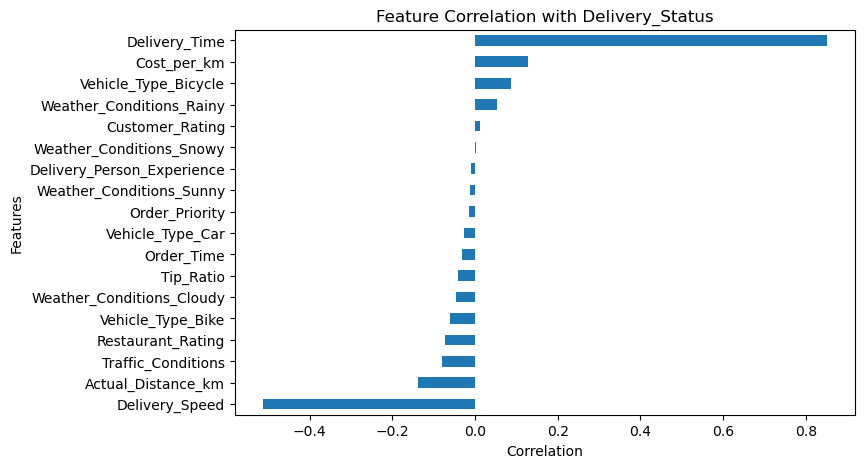

In [14]:
import matplotlib.pyplot as plt

target_corr.sort_values().plot(kind='barh', figsize=(8,5))

plt.title("Feature Correlation with Delivery_Status")
plt.xlabel("Correlation")
plt.ylabel("Features")
plt.show()

In [15]:
df['Delivery_Status'].value_counts()

Delivery_Status
1    104
0     96
Name: count, dtype: int64

In [16]:
df.head()

,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Restaurant_Rating,Customer_Rating,Delivery_Time,Actual_Distance_km,Cost_per_km,Tip_Ratio,Delivery_Speed,Distance_Category,Vehicle_Type_Bicycle,Vehicle_Type_Bike,Vehicle_Type_Car,Weather_Conditions_Cloudy,Weather_Conditions_Rainy,Weather_Conditions_Snowy,Weather_Conditions_Sunny,Delivery_Status
0,1,4,1,0,4.1,3.0,26.22,775.651198,1.703214,0.061721,29.582426,3,False,False,True,False,True,False,False,0
1,1,8,0,1,4.5,4.2,62.61,1042.385597,0.146021,0.190658,16.648868,4,False,False,True,True,False,False,False,0
2,1,9,2,1,3.3,3.4,48.43,476.220706,3.452979,0.039024,9.833176,2,False,True,False,False,False,True,False,0
3,0,2,1,2,3.2,3.7,111.63,389.912629,1.388131,0.146383,3.492902,2,False,True,False,True,False,False,False,1
4,2,6,0,1,3.5,2.8,32.38,806.505886,0.768513,0.003775,24.907532,3,False,True,False,False,True,False,False,0


In [17]:
from sklearn.preprocessing import MinMaxScaler
num_cols=['Delivery_Person_Experience',
          'Restaurant_Rating','Customer_Rating','Delivery_Time','Actual_Distance_km','Cost_per_km','Tip_Ratio','Delivery_Speed']

scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])
df[num_cols].head()
df.head()

,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Restaurant_Rating,Customer_Rating,Delivery_Time,Actual_Distance_km,Cost_per_km,Tip_Ratio,Delivery_Speed,Distance_Category,Vehicle_Type_Bicycle,Vehicle_Type_Bike,Vehicle_Type_Car,Weather_Conditions_Cloudy,Weather_Conditions_Rainy,Weather_Conditions_Snowy,Weather_Conditions_Sunny,Delivery_Status
0,1,0.333333,1,0,0.64,0.166667,0.105228,0.587518,0.124049,0.114855,0.383436,3,False,False,True,False,True,False,False,0
1,1,0.777778,0,1,0.80,0.666667,0.453658,0.797649,0.000185,0.358695,0.214193,4,False,False,True,True,False,False,False,0
2,1,0.888889,2,1,0.32,0.333333,0.317886,0.351630,0.263230,0.071930,0.125007,2,False,True,False,False,False,True,False,0
3,0,0.111111,1,2,0.28,0.458333,0.923018,0.283637,0.098986,0.274965,0.042041,2,False,True,False,True,False,False,False,1
4,2,0.555556,0,1,0.40,0.083333,0.164209,0.611825,0.049700,0.005269,0.322262,3,False,True,False,False,True,False,False,0


In [18]:
X=df.drop(['Delivery_Time','Delivery_Status'],axis=1)
y=df['Delivery_Status']
X.head()

,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Restaurant_Rating,Customer_Rating,Actual_Distance_km,Cost_per_km,Tip_Ratio,Delivery_Speed,Distance_Category,Vehicle_Type_Bicycle,Vehicle_Type_Bike,Vehicle_Type_Car,Weather_Conditions_Cloudy,Weather_Conditions_Rainy,Weather_Conditions_Snowy,Weather_Conditions_Sunny
0,1,0.333333,1,0,0.64,0.166667,0.587518,0.124049,0.114855,0.383436,3,False,False,True,False,True,False,False
1,1,0.777778,0,1,0.80,0.666667,0.797649,0.000185,0.358695,0.214193,4,False,False,True,True,False,False,False
2,1,0.888889,2,1,0.32,0.333333,0.351630,0.263230,0.071930,0.125007,2,False,True,False,False,False,True,False
3,0,0.111111,1,2,0.28,0.458333,0.283637,0.098986,0.274965,0.042041,2,False,True,False,True,False,False,False
4,2,0.555556,0,1,0.40,0.083333,0.611825,0.049700,0.005269,0.322262,3,False,True,False,False,True,False,False


In [19]:
#X=X.drop(['Delivery_Person_Experience','Restaurant_Rating','Customer_Rating'],axis=1)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
X.head()

,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Restaurant_Rating,Customer_Rating,Actual_Distance_km,Cost_per_km,Tip_Ratio,Delivery_Speed,Distance_Category,Vehicle_Type_Bicycle,Vehicle_Type_Bike,Vehicle_Type_Car,Weather_Conditions_Cloudy,Weather_Conditions_Rainy,Weather_Conditions_Snowy,Weather_Conditions_Sunny
0,1,0.333333,1,0,0.64,0.166667,0.587518,0.124049,0.114855,0.383436,3,False,False,True,False,True,False,False
1,1,0.777778,0,1,0.80,0.666667,0.797649,0.000185,0.358695,0.214193,4,False,False,True,True,False,False,False
2,1,0.888889,2,1,0.32,0.333333,0.351630,0.263230,0.071930,0.125007,2,False,True,False,False,False,True,False
3,0,0.111111,1,2,0.28,0.458333,0.283637,0.098986,0.274965,0.042041,2,False,True,False,True,False,False,False
4,2,0.555556,0,1,0.40,0.083333,0.611825,0.049700,0.005269,0.322262,3,False,True,False,False,True,False,False


In [22]:
X_train.head()

,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Restaurant_Rating,Customer_Rating,Actual_Distance_km,Cost_per_km,Tip_Ratio,Delivery_Speed,Distance_Category,Vehicle_Type_Bicycle,Vehicle_Type_Bike,Vehicle_Type_Car,Weather_Conditions_Cloudy,Weather_Conditions_Rainy,Weather_Conditions_Snowy,Weather_Conditions_Sunny
79,2,0.666667,2,0,0.84,0.083333,0.346294,0.163111,0.153280,0.114401,2,True,False,False,False,False,True,False
197,2,0.333333,1,0,0.16,0.333333,0.060514,1.000000,0.005239,0.015406,1,False,True,False,False,False,True,False
38,0,0.888889,1,0,0.56,0.291667,0.465708,0.045347,0.018608,0.133098,2,False,False,True,False,False,False,True
24,1,0.444444,1,2,0.24,0.833333,0.573861,0.186612,0.019805,0.090302,3,False,True,False,False,False,False,True
122,1,0.888889,2,1,0.48,0.208333,0.436249,0.016980,0.151909,0.065574,2,True,False,False,False,False,False,True


In [23]:
naive = GaussianNB()
naive.fit(X_train, y_train)

GaussianNB()

In [24]:
y_pred_naive = naive.predict(X_test)

In [25]:
print("Accuracy:", accuracy_score(y_test, y_pred_naive))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_naive))
print("Classification Report:\n", classification_report(y_test, y_pred_naive))

Accuracy: 0.75
Confusion Matrix:
 [[12  6]
 [ 4 18]]
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.67      0.71        18
           1       0.75      0.82      0.78        22

    accuracy                           0.75        40
   macro avg       0.75      0.74      0.74        40
weighted avg       0.75      0.75      0.75        40



In [26]:
X=X.drop(['Delivery_Person_Experience','Restaurant_Rating','Customer_Rating'],axis=1)

In [27]:
X=X.drop(['Order_Time'],axis=1)

In [28]:
X=X.drop(['Distance_Category'],axis=1)

In [29]:
X=X.drop(['Traffic_Conditions'],axis=1)

In [30]:
X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
X_train_knn.head()

,Order_Priority,Actual_Distance_km,Cost_per_km,Tip_Ratio,Delivery_Speed,Vehicle_Type_Bicycle,Vehicle_Type_Bike,Vehicle_Type_Car,Weather_Conditions_Cloudy,Weather_Conditions_Rainy,Weather_Conditions_Snowy,Weather_Conditions_Sunny
79,2,0.346294,0.163111,0.153280,0.114401,True,False,False,False,False,True,False
197,1,0.060514,1.000000,0.005239,0.015406,False,True,False,False,False,True,False
38,1,0.465708,0.045347,0.018608,0.133098,False,False,True,False,False,False,True
24,1,0.573861,0.186612,0.019805,0.090302,False,True,False,False,False,False,True
122,2,0.436249,0.016980,0.151909,0.065574,True,False,False,False,False,False,True


In [32]:
k_values = range(1, 31)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_knn, y_train_knn, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

best_k = k_values[np.argmax(cv_scores)]
print("Best K =", best_k)

Best K = 21


In [33]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_knn, y_train_knn)

KNeighborsClassifier(n_neighbors=21)

In [34]:
y_pred_knn=knn.predict(X_test_knn)

In [35]:
acc = accuracy_score(y_test_knn, y_pred_knn)
print("Accuracy for knn model:", acc)
cm = confusion_matrix(y_test_knn, y_pred_knn)
print("Confusion Matrix of knn model:\n", cm)
precision = precision_score(y_test_knn, y_pred_knn)
print("Precision of knn:", precision)
print('Recall of knn:',recall_score(y_test_knn,y_pred_knn))
print('F1 score of knn:',f1_score(y_test_knn,y_pred_knn))

Accuracy for knn model: 0.6
Confusion Matrix of knn model:
 [[ 9  9]
 [ 7 15]]
Precision of knn: 0.625
Recall of knn: 0.6818181818181818
F1 score of knn: 0.6521739130434783


In [23]:
ordinal_maps = {
    'Order_Priority': {'Low':0, 'Medium':1, 'High':2},
    'Traffic_Conditions': {'Low':0, 'Medium':1, 'High':2},
    'Order_Time':{'Afternoon':3,'Evening':2,'Night':1,'Morning':0}
   # 'Weather_Conditions':{'Car':0,'Bike':1,"Bicycle":2}
}

for col in ordinal_features:
    df[col] = df[col].map(ordinal_maps[col])
#df = pd.get_dummies(df, columns=['Vehicle_Type'])
#df=df.drop(['Weather_Conditions','Vehicle_Type'],axis=1)

In [24]:
threshold = df["Delivery_Time"].mean()
df["Delivery_Status"] = (df["Delivery_Time"] > threshold).astype(int)

In [36]:
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
dtree = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    random_state=42
)
dtree.fit(X_train_dt, y_train_dt)

DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)

In [39]:
y_pred_dt=dtree.predict(X_test_dt)

In [40]:
print('---FOR DECISION TREE---')
acc = accuracy_score(y_test_dt, y_pred_dt)
print("Accuracy of dtree:", acc)
cm = confusion_matrix(y_test_dt, y_pred_dt)
print("Confusion Matrix:\n", cm)
precision = precision_score(y_test_dt, y_pred_dt)
print("Precision:", precision)
print('Recall:',recall_score(y_test_dt,y_pred_dt))
print('F1 score:',f1_score(y_test_dt,y_pred_dt))

---FOR DECISION TREE---
Accuracy of dtree: 0.875
Confusion Matrix:
 [[17  1]
 [ 4 18]]
Precision: 0.9473684210526315
Recall: 0.8181818181818182
F1 score: 0.8780487804878049


In [41]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = pd.DataFrame({
    "Model": ["KNN","Naive Bayes","Decision Tree"],
    "Accuracy":[accuracy_score(y_test_knn,y_pred_knn),
                accuracy_score(y_test,y_pred_naive),
                accuracy_score(y_test_dt,y_pred_dt)],
    "Precision":[precision_score(y_test_knn,y_pred_knn),
                 precision_score(y_test,y_pred_naive),
                 precision_score(y_test_dt,y_pred_dt)],
    "Recall":[recall_score(y_test_knn,y_pred_knn),
              recall_score(y_test,y_pred_naive),
              recall_score(y_test_dt,y_pred_dt)],
    "F1 Score":[f1_score(y_test_knn,y_pred_knn),
                f1_score(y_test,y_pred_naive),
                f1_score(y_test_dt,y_pred_dt)]
})



print(results)

           Model  Accuracy  Precision    Recall  F1 Score
0            KNN     0.600   0.625000  0.681818  0.652174
1    Naive Bayes     0.750   0.750000  0.818182  0.782609
2  Decision Tree     0.875   0.947368  0.818182  0.878049


In [42]:
import matplotlib.pyplot as plt

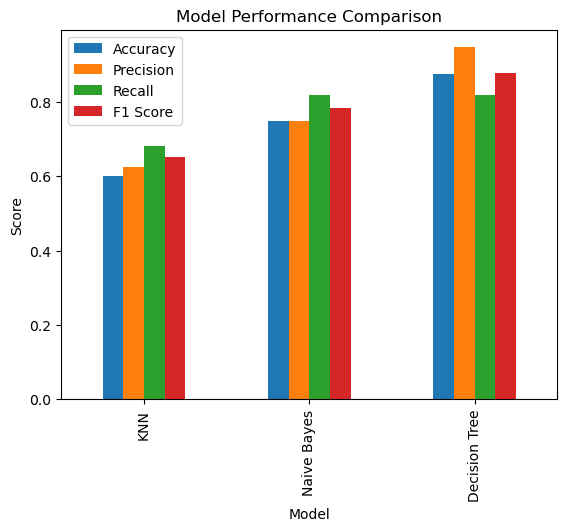

In [43]:
results.set_index("Model").plot(kind="bar")
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.show()

In [46]:
from sklearn.metrics import roc_curve, auc

knn_prob = knn.predict_proba(X_test_knn)[:,1]
nb_prob = naive.predict_proba(X_test)[:,1]
dt_prob = dtree.predict_proba(X_test_dt)[:,1]

In [47]:
fpr_knn, tpr_knn, _ = roc_curve(y_test_knn, knn_prob)
fpr_nb, tpr_nb, _ = roc_curve(y_test, nb_prob)
fpr_dt, tpr_dt, _ = roc_curve(y_test_dt, dt_prob)

In [48]:
auc_knn = auc(fpr_knn, tpr_knn)
auc_nb = auc(fpr_nb, tpr_nb)
auc_dt = auc(fpr_dt, tpr_dt)

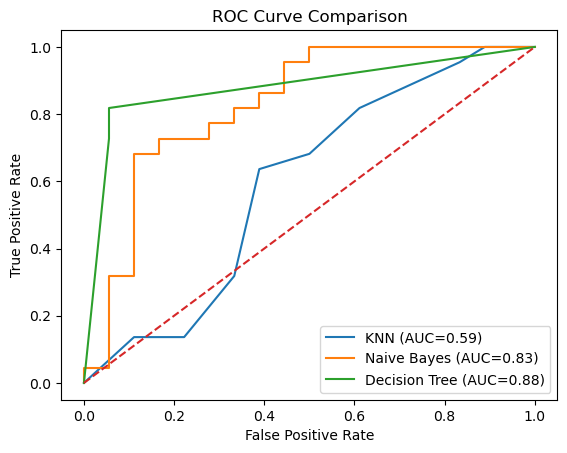

In [49]:
plt.figure()

plt.plot(fpr_knn, tpr_knn, label="KNN (AUC="+str(round(auc_knn,2))+")")
plt.plot(fpr_nb, tpr_nb, label="Naive Bayes (AUC="+str(round(auc_nb,2))+")")
plt.plot(fpr_dt, tpr_dt, label="Decision Tree (AUC="+str(round(auc_dt,2))+")")

plt.plot([0,1],[0,1],'--')  # random model line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()